# COMP 3610: Big Data Analytics - Assignment 2
## ML Model Training & Evaluation

**Student ID:** 816040879


# Part 0: Environment Setup

In [ ]:
pip install -r requirements.txt

In [2]:
import importlib

pkgs = [
    "torch", "numpy", "pandas", "sklearn",
    "matplotlib", "seaborn", "shap", "requests", "pyarrow",
]

print("Package Versions")
print("-" * 30)
for pkg_name in pkgs:
    try:
        mod = importlib.import_module(pkg_name)
        ver = getattr(mod, "__version__", "n/a")
        print(f"  {pkg_name:<15} {ver}")
    except Exception as e:
        print(f"  {pkg_name:<15} NOT FOUND")
print("-" * 30)

Package Versions
------------------------------
  torch           2.6.0+cu124
  numpy           2.3.2
  pandas          2.3.1
  sklearn         1.8.0
  matplotlib      3.10.8
  seaborn         0.13.2
  shap            0.51.0
  requests        2.32.4
  pyarrow         18.1.0
------------------------------


In [3]:
import warnings
warnings.filterwarnings('ignore')

import shap
from pathlib import Path
from datetime import datetime

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED    = 42
EPOCHS  = 20
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", "{:.4f}".format)

print(f"cuda available : {torch.cuda.is_available()}")
print(f"device name    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")
print(f"torch version  : {torch.__version__}")

cuda available : True
device name    : NVIDIA GeForce RTX 4050 Laptop GPU
torch version  : 2.6.0+cu124


---

# Part 1: Data Preprocessing & Feature Engineering

## 1.0 Download Data

download_file function modified from assignment 1

In [4]:
TRIP_URL  = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_URL  = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

RAW_DIR        = Path("data/raw")
TRIP_PATH      = RAW_DIR / "yellow_tripdata_2024-01.parquet"
ZONE_PATH      = RAW_DIR / "taxi_zone_lookup.csv"


def download_file(url: str, dest: Path, chunk: int = 8192) -> bool:
    try:
        dest.parent.mkdir(parents=True, exist_ok=True)
        r = requests.get(url, stream=True, timeout=60)
        r.raise_for_status()
        total, done = int(r.headers.get("content-length", 0)), 0
        with open(dest, "wb") as f:
            for block in r.iter_content(chunk_size=chunk):
                if block:
                    f.write(block)
                    done += len(block)
                    if total:
                        print(f"\r  {done/total*100:5.1f}%  [{done//(1024**2)} MB]", end="")
        print(f"\n  saved -> {dest.name}  ({done/(1024**2):.1f} MB)")
        return True
    except Exception as err:
        print(f"  failed: {err}")
        return False


if not TRIP_PATH.exists():
    print("Downloading trip data...")
    download_file(TRIP_URL, TRIP_PATH)

if not ZONE_PATH.exists():
    print("Downloading zone lookup...")
    download_file(ZONE_URL, ZONE_PATH)

print("Data files ready.")

Data files ready.


## 1.1 Load Raw Data

In [5]:
raw_df      = pd.read_parquet(TRIP_PATH)
zones_df    = pd.read_csv(ZONE_PATH)

print(f"  trip records : {len(raw_df):>10,}")
print(f"  trip columns : {raw_df.shape[1]:>10}")
print(f"  zone records : {len(zones_df):>10,}")
raw_df.head()

  trip records :  2,964,624
  trip columns :         19
  zone records :        265


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0000,1.7200,1.0000,N,186,79,2,17.7000,1.0000,0.5000,0.0000,0.0000,1.0000,22.7000,2.5000,0.0000
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0000,1.8000,1.0000,N,140,236,1,10.0000,3.5000,0.5000,3.7500,0.0000,1.0000,18.7500,2.5000,0.0000
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0000,4.7000,1.0000,N,236,79,1,23.3000,3.5000,0.5000,3.0000,0.0000,1.0000,31.3000,2.5000,0.0000
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0000,1.4000,1.0000,N,79,211,1,10.0000,3.5000,0.5000,2.0000,0.0000,1.0000,17.0000,2.5000,0.0000
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0000,0.8000,1.0000,N,211,148,1,7.9000,3.5000,0.5000,3.2000,0.0000,1.0000,16.1000,2.5000,0.0000


## 1.2 Data Cleaning

Builds on the `clean_trip_data` logic from Assignment 1, with an additional filter for credit card payments (`payment_type = 1`) since `tip_amount` is only reliably recorded for these transactions.

In [6]:
def clean_trip_data(df: pd.DataFrame) -> pd.DataFrame:
    n0 = len(df)
    steps = []

    df = df[df["payment_type"] == 1].copy()
    steps.append(("credit card only",       len(df)))

    critical = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
                "PULocationID", "DOLocationID", "fare_amount"]
    df = df.dropna(subset=critical)
    steps.append(("drop critical nulls",    len(df)))

    df = df[(df["trip_distance"] > 0) & (df["trip_distance"] <= 100)]
    steps.append(("valid distance",         len(df)))

    df = df[(df["fare_amount"] > 0) & (df["fare_amount"] < 500)]
    steps.append(("valid fare",             len(df)))

    df = df[df["tip_amount"] >= 0]
    steps.append(("non-negative tip",       len(df)))

    df = df.dropna(subset=["passenger_count"])
    df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]
    steps.append(("valid passenger count",  len(df)))

    df = df[df["tpep_dropoff_datetime"] > df["tpep_pickup_datetime"]]
    steps.append(("valid trip direction",   len(df)))

    df["trip_duration_seconds"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds()
    df = df[(df["trip_duration_seconds"] >= 60) & (df["trip_duration_seconds"] <= 10800)]
    steps.append(("valid duration",         len(df)))

    df = df[
        (df["tpep_pickup_datetime"] >= datetime(2024, 1, 1)) &
        (df["tpep_pickup_datetime"] <  datetime(2024, 2, 1))
    ]
    steps.append(("january 2024 only",      len(df)))

    df = df[df["tip_amount"] <= 100]
    steps.append(("tip outlier cap",        len(df)))

    print(f"{'step':<26} {'rows':>10}  {'removed':>10}")
    print("-" * 50)
    prev = n0
    for label, n in steps:
        print(f"  {label:<24} {n:>10,}  {prev-n:>10,}")
        prev = n
    print("-" * 50)
    print(f"  {'total removed':<24} {n0-len(df):>10,}  ({(n0-len(df))/n0*100:.1f}%)")
    print(f"  {'remaining':<24} {len(df):>10,}  ({len(df)/n0*100:.1f}%)")

    return df.reset_index(drop=True)


clean_df = clean_trip_data(raw_df)

step                             rows     removed
--------------------------------------------------
  credit card only          2,319,046     645,578
  drop critical nulls       2,319,046           0
  valid distance            2,298,423      20,623
  valid fare                2,298,370          53
  non-negative tip          2,298,370           0
  valid passenger count     2,273,521      24,849
  valid trip direction      2,273,481          40
  valid duration            2,268,610       4,871
  january 2024 only         2,268,600          10
  tip outlier cap           2,268,587          13
--------------------------------------------------
  total removed               696,037  (23.5%)
  remaining                 2,268,587  (76.5%)


## 1.3 Feature Engineering

In [7]:
def engineer_features(df: pd.DataFrame, zone_lkp: pd.DataFrame):
    df = df.copy()
    df["tpep_pickup_datetime"]  = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

    # a) temporal
    df["pickup_hour"]        = df["tpep_pickup_datetime"].dt.hour
    df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
    df["is_weekend"]         = df["pickup_day_of_week"].isin([5, 6]).astype(int)

    # b) trip
    df["trip_duration_minutes"] = df["trip_duration_seconds"] / 60
    df["trip_speed_mph"] = np.where(
        df["trip_duration_minutes"] > 0,
        df["trip_distance"] / (df["trip_duration_minutes"] / 60), 0
    ).clip(max=80)
    df["log_trip_distance"] = np.log1p(df["trip_distance"])

    # c) fare
    df["fare_per_mile"] = np.where(
        df["trip_distance"] > 0,
        df["fare_amount"] / df["trip_distance"], 0
    ).clip(max=100)
    df["fare_per_minute"] = np.where(
        df["trip_duration_minutes"] > 0,
        df["fare_amount"] / df["trip_duration_minutes"], 0
    ).clip(max=50)

    # d) zone / borough (label encoded)
    borough_map = dict(zip(zone_lkp["LocationID"], zone_lkp["Borough"]))
    df["pickup_borough"]  = df["PULocationID"].map(borough_map).fillna("Unknown")
    df["dropoff_borough"] = df["DOLocationID"].map(borough_map).fillna("Unknown")

    enc_pu = LabelEncoder()
    enc_do = LabelEncoder()
    df["pickup_borough_encoded"]  = enc_pu.fit_transform(df["pickup_borough"])
    df["dropoff_borough_encoded"] = enc_do.fit_transform(df["dropoff_borough"])

    pu_enc = dict(zip(enc_pu.classes_, enc_pu.transform(enc_pu.classes_)))
    do_enc = dict(zip(enc_do.classes_, enc_do.transform(enc_do.classes_)))

    print("Borough Encoding")
    print("=" * 40)
    print(f"  Pickup:  {pu_enc}")
    print(f"  Dropoff: {do_enc}")
    print("=" * 40)
    print(f"  features engineered: {len([c for c in df.columns if c not in clean_df.columns])}")
    print("=" * 40)

    return df, enc_pu, enc_do


model_df, le_pickup, le_dropoff = engineer_features(clean_df, zones_df)

Borough Encoding
  Pickup:  {'Bronx': np.int64(0), 'Brooklyn': np.int64(1), 'EWR': np.int64(2), 'Manhattan': np.int64(3), 'Queens': np.int64(4), 'Staten Island': np.int64(5), 'Unknown': np.int64(6)}
  Dropoff: {'Bronx': np.int64(0), 'Brooklyn': np.int64(1), 'EWR': np.int64(2), 'Manhattan': np.int64(3), 'Queens': np.int64(4), 'Staten Island': np.int64(5), 'Unknown': np.int64(6)}
  features engineered: 12


## 1.4 Target Variable Creation

In [8]:
model_df["high_tip"] = (model_df["tip_amount"] > 0.20 * model_df["fare_amount"]).astype(int)

n_total  = len(model_df)
n_low    = (model_df["high_tip"] == 0).sum()
n_high   = (model_df["high_tip"] == 1).sum()

print("Target Variables")
print("=" * 45)
print("  tip_amount (regression)")
stats = model_df["tip_amount"].describe()
for k, v in stats.items():
    print(f"    {k:<8} {v:.4f}")
print()
print("  high_tip (classification)")
print(f"    low  (0) : {n_low:>10,}  ({n_low/n_total*100:.2f}%)")
print(f"    high (1) : {n_high:>10,}  ({n_high/n_total*100:.2f}%)")
print("=" * 45)

Target Variables
  tip_amount (regression)
    count    2268587.0000
    mean     4.1511
    std      3.8057
    min      0.0000
    25%      2.1500
    50%      3.1400
    75%      4.6600
    max      100.0000

  high_tip (classification)
    low  (0) :    545,001  (24.02%)
    high (1) :  1,723,586  (75.98%)


## 1.5 Data Splitting & Scaling

In [9]:
FEATURES = [
    "pickup_hour", "pickup_day_of_week", "is_weekend",
    "trip_distance", "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_amount", "fare_per_mile", "fare_per_minute",
    "passenger_count",
    "pickup_borough_encoded", "dropoff_borough_encoded",
    "tolls_amount", "extra", "mta_tax", "congestion_surcharge", "Airport_fee",
]

DROPPED = {
    "tip_amount":            "regression target",
    "high_tip":              "classification target",
    "total_amount":          "data leakage (includes tip)",
    "tpep_pickup_datetime":  "datetime - temporal features extracted",
    "tpep_dropoff_datetime": "datetime - temporal features extracted",
    "payment_type":          "constant after filtering (all credit card)",
    "PULocationID":          "raw zone id - using borough encoding",
    "DOLocationID":          "raw zone id - using borough encoding",
    "pickup_borough":        "string - using encoded version",
    "dropoff_borough":       "string - using encoded version",
    "trip_duration_seconds": "using minutes instead",
    "VendorID":              "vendor identifier not predictive",
    "RatecodeID":            "not encoded",
    "store_and_fwd_flag":    "not relevant",
    "improvement_surcharge": "constant value",
}

print(f"Features used ({len(FEATURES)}):")
print("-" * 45)
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}.  {f}")

print(f"\nExcluded ({len(DROPPED)}):")
print("-" * 45)
for f, reason in DROPPED.items():
    print(f"  {f:<28}  {reason}")

Features used (18):
---------------------------------------------
   1.  pickup_hour
   2.  pickup_day_of_week
   3.  is_weekend
   4.  trip_distance
   5.  trip_duration_minutes
   6.  trip_speed_mph
   7.  log_trip_distance
   8.  fare_amount
   9.  fare_per_mile
  10.  fare_per_minute
  11.  passenger_count
  12.  pickup_borough_encoded
  13.  dropoff_borough_encoded
  14.  tolls_amount
  15.  extra
  16.  mta_tax
  17.  congestion_surcharge
  18.  Airport_fee

Excluded (15):
---------------------------------------------
  tip_amount                    regression target
  high_tip                      classification target
  total_amount                  data leakage (includes tip)
  tpep_pickup_datetime          datetime - temporal features extracted
  tpep_dropoff_datetime         datetime - temporal features extracted
  payment_type                  constant after filtering (all credit card)
  PULocationID                  raw zone id - using borough encoding
  DOLocationID      

In [10]:
for col in FEATURES:
    if model_df[col].isnull().any():
        model_df[col].fillna(model_df[col].median(), inplace=True)

X     = model_df[FEATURES].values
y_reg = model_df["tip_amount"].values
y_cls = model_df["high_tip"].values

X_tr, X_tmp, y_reg_tr, y_reg_tmp, y_cls_tr, y_cls_tmp = train_test_split(
    X, y_reg, y_cls, test_size=0.30, random_state=SEED, stratify=y_cls
)
X_vl, X_te, y_reg_vl, y_reg_te, y_cls_vl, y_cls_te = train_test_split(
    X_tmp, y_reg_tmp, y_cls_tmp,
    test_size=0.50, random_state=SEED, stratify=y_cls_tmp
)

feat_scaler = StandardScaler()
X_tr = feat_scaler.fit_transform(X_tr)
X_vl = feat_scaler.transform(X_vl)
X_te = feat_scaler.transform(X_te)

N = len(model_df)
print(f"{'split':<14} {'rows':>10}  {'pct':>6}  {'high_tip%':>10}")
print("-" * 46)
for tag, arr, y in [("train", X_tr, y_cls_tr), ("validation", X_vl, y_cls_vl), ("test", X_te, y_cls_te)]:
    print(f"  {tag:<12} {len(arr):>10,}  {len(arr)/N*100:>5.1f}%  {y.mean()*100:>9.2f}%")
print("-" * 46)
print(f"  {'total':<12} {N:>10,}  100.0%")

split                rows     pct   high_tip%
----------------------------------------------
  train         1,588,010   70.0%      75.98%
  validation      340,288   15.0%      75.98%
  test            340,289   15.0%      75.98%
----------------------------------------------
  total         2,268,587  100.0%


---

# Part 2: Model Training & Tuning

## 4. Baseline Models

In [11]:
# returns MAE, RMSE, R2 and predictions for a regression model
def eval_regression(model, X, y, name):
    pred = model.predict(X)
    return {"Model": name,
            "MAE":   mean_absolute_error(y, pred),
            "RMSE":  np.sqrt(mean_squared_error(y, pred)),
            "R2":    r2_score(y, pred)}, pred

# returns accuracy, precision, recall, F1, AUC-ROC and predictions for a classification model
def eval_classification(model, X, y, name):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None
    return {"Model":     name,
            "Accuracy":  accuracy_score(y, pred),
            "Precision": precision_score(y, pred, zero_division=0),
            "Recall":    recall_score(y, pred, zero_division=0),
            "F1":        f1_score(y, pred, zero_division=0),
            "AUC-ROC":   roc_auc_score(y, prob) if prob is not None else None}, pred, prob

### 4a. Regression Baselines

In [12]:
# linear regression baseline
regressors  = {}
reg_scores  = []

print("[ training ] Linear Regression")
lin_reg = LinearRegression()
lin_reg.fit(X_tr, y_reg_tr)
regressors["Linear Regression"] = lin_reg
s, _ = eval_regression(lin_reg, X_vl, y_reg_vl, "Linear Regression")
reg_scores.append(s)
print(f"  -> MAE {s['MAE']:.4f}   RMSE {s['RMSE']:.4f}   R2 {s['R2']:.4f}")

# random forest baseline
print("\n[ training ] Random Forest Regressor")
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15,
                                min_samples_split=10, min_samples_leaf=5,
                                n_jobs=-1, random_state=SEED)
rf_reg.fit(X_tr, y_reg_tr)
regressors["RF Regressor"] = rf_reg
s, _ = eval_regression(rf_reg, X_vl, y_reg_vl, "RF Regressor")
reg_scores.append(s)
print(f"  -> MAE {s['MAE']:.4f}   RMSE {s['RMSE']:.4f}   R2 {s['R2']:.4f}")

# validation results
pd.DataFrame(reg_scores)

[ training ] Linear Regression
  -> MAE 1.2480   RMSE 2.3323   R2 0.6239

[ training ] Random Forest Regressor
  -> MAE 1.1785   RMSE 2.2573   R2 0.6477


,Model,MAE,RMSE,R2
0,Linear Regression,1.2480,2.3323,0.6239
1,RF Regressor,1.1785,2.2573,0.6477


### 4b. Classification Baselines

In [13]:
# logistic regression baseline
classifiers = {}
clf_scores  = []

print("[ training ] Logistic Regression")
log_reg = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
log_reg.fit(X_tr, y_cls_tr)
classifiers["Logistic Regression"] = log_reg
s, _, _ = eval_classification(log_reg, X_vl, y_cls_vl, "Logistic Regression")
clf_scores.append(s)
print(f"  -> Acc {s['Accuracy']:.4f}   F1 {s['F1']:.4f}   AUC {s['AUC-ROC']:.4f}")

# random forest baseline
print("\n[ training ] Random Forest Classifier")
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15,
                                 min_samples_split=10, min_samples_leaf=5,
                                 n_jobs=-1, random_state=SEED)
rf_clf.fit(X_tr, y_cls_tr)
classifiers["RF Classifier"] = rf_clf
s, _, _ = eval_classification(rf_clf, X_vl, y_cls_vl, "RF Classifier")
clf_scores.append(s)
print(f"  -> Acc {s['Accuracy']:.4f}   F1 {s['F1']:.4f}   AUC {s['AUC-ROC']:.4f}")

# validation results
pd.DataFrame(clf_scores)

[ training ] Logistic Regression
  -> Acc 0.7681   F1 0.8670   AUC 0.6056

[ training ] Random Forest Classifier
  -> Acc 0.7713   F1 0.8690   AUC 0.6228


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.7681,0.7683,0.9947,0.8670,0.6056
1,RF Classifier,0.7713,0.7694,0.9981,0.8690,0.6228


## 5. Hyperparameter Tuning

Using a stratified sample of 200,000 rows (`random_state=42`) to keep runtimes manageable, then retraining on the full training set with the best parameters found.

In [14]:
TUNE_SAMPLE = 200_000

all_idx = np.arange(len(X_tr))
tune_idx, _ = train_test_split(
    all_idx, train_size=TUNE_SAMPLE, stratify=y_cls_tr, random_state=SEED
)
X_tune     = X_tr[tune_idx]
y_reg_tune = y_reg_tr[tune_idx]
y_cls_tune = y_cls_tr[tune_idx]

dist = np.bincount(y_cls_tune.astype(int))
print(f"  tuning sample size : {TUNE_SAMPLE:,}")
print(f"  class distribution : low={dist[0]:,}  high={dist[1]:,}")

  tuning sample size : 200,000
  class distribution : low=48,048  high=151,952


In [15]:
# search space for RF regressor hyperparameter tuning
reg_params = {
    "n_estimators":      [50, 100, 200, 300],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

print("RF Regressor search space:")
for k, v in reg_params.items():
    print(f"  {k:<20} {v}")

# 20 iterations, 5-fold CV, scored on R2
search_reg = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=SEED),
    reg_params, n_iter=20, cv=5, scoring="r2",
    n_jobs=-1, random_state=SEED, verbose=1
)
search_reg.fit(X_tune, y_reg_tune)

print(f"\n  best CV R2     : {search_reg.best_score_:.4f}")
print(f"  best params    : {search_reg.best_params_}")

RF Regressor search space:
  n_estimators         [50, 100, 200, 300]
  max_depth            [None, 10, 20, 30]
  min_samples_split    [2, 5, 10]
  min_samples_leaf     [1, 2, 4]
  max_features         ['sqrt', 'log2']
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  best CV R2     : 0.6392
  best params    : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}


In [16]:
# retrain best estimator on full training data
rf_reg_best = search_reg.best_estimator_
rf_reg_best.fit(X_tr, y_reg_tr)
regressors["RF Regressor (Tuned)"] = rf_reg_best

# compare baseline vs tuned on validation set
base_scores, _ = eval_regression(regressors["RF Regressor"], X_vl, y_reg_vl, "RF Regressor")
tuned_scores, _ = eval_regression(rf_reg_best,               X_vl, y_reg_vl, "RF Regressor (Tuned)")
reg_scores.append(tuned_scores)

print("Baseline vs Tuned (Validation):")
pd.DataFrame([base_scores, tuned_scores])

Baseline vs Tuned (Validation):


,Model,MAE,RMSE,R2
0,RF Regressor,1.1785,2.2573,0.6477
1,RF Regressor (Tuned),1.1897,2.2558,0.6481


In [17]:
# search space for RF classifier hyperparameter tuning, 20 iterations, 5-fold CV, scored on AUC-ROC
clf_params = {
    "n_estimators":      [50, 100, 200, 300],
    "max_depth":         [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

search_clf = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=SEED),
    clf_params, n_iter=20, cv=5, scoring="roc_auc",
    n_jobs=-1, random_state=SEED, verbose=1
)
search_clf.fit(X_tune, y_cls_tune)

print(f"  best CV AUC-ROC : {search_clf.best_score_:.4f}")
print(f"  best params     : {search_clf.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
  best CV AUC-ROC : 0.6209
  best params     : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}


In [18]:
# retrain best estimator on full training data
rf_clf_best = search_clf.best_estimator_
rf_clf_best.fit(X_tr, y_cls_tr)
classifiers["RF Classifier (Tuned)"] = rf_clf_best

# compare baseline vs tuned on validation set
base_scores, _, _ = eval_classification(classifiers["RF Classifier"], X_vl, y_cls_vl, "RF Classifier")
tuned_scores, _, _ = eval_classification(rf_clf_best,                 X_vl, y_cls_vl, "RF Classifier (Tuned)")
clf_scores.append(tuned_scores)

print("Baseline vs Tuned (Validation):")
pd.DataFrame([base_scores, tuned_scores])

Baseline vs Tuned (Validation):


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,RF Classifier,0.7713,0.7694,0.9981,0.8690,0.6228
1,RF Classifier (Tuned),0.7712,0.7691,0.9986,0.8690,0.6209


## 6. Neural Network Model

Feedforward network for the classification task (`high_tip`). Two hidden layers with ReLU + Dropout, `BCEWithLogitsLoss`, Adam optimizer, 20 epochs.

In [19]:
# feedforward NN: input -> 128 -> 64 -> 1, ReLU + Dropout(0.3) between layers
class TipClassifier(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# regression NN: same architecture, MSELoss instead of BCEWithLogitsLoss
class TipRegressor(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [20]:
# use GPU if available
compute_dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# tensors
tr_tensor   = torch.tensor(X_tr,      dtype=torch.float32)
vl_tensor   = torch.tensor(X_vl,      dtype=torch.float32)
te_tensor   = torch.tensor(X_te,      dtype=torch.float32)
y_tr_tensor = torch.tensor(y_cls_tr,  dtype=torch.float32).view(-1, 1)
y_vl_tensor = torch.tensor(y_cls_vl,  dtype=torch.float32).view(-1, 1)
y_te_tensor = torch.tensor(y_cls_te,  dtype=torch.float32).view(-1, 1)

# regression targets
y_reg_tr_tensor = torch.tensor(y_reg_tr, dtype=torch.float32).view(-1, 1)
y_reg_vl_tensor = torch.tensor(y_reg_vl, dtype=torch.float32).view(-1, 1)
y_reg_te_tensor = torch.tensor(y_reg_te, dtype=torch.float32).view(-1, 1)

# dataloaders - classification
tr_loader = DataLoader(TensorDataset(tr_tensor, y_tr_tensor),      batch_size=512, shuffle=True)
vl_loader = DataLoader(TensorDataset(vl_tensor, y_vl_tensor),      batch_size=512, shuffle=False)
te_loader = DataLoader(TensorDataset(te_tensor, y_te_tensor),      batch_size=512, shuffle=False)

# dataloaders - regression
tr_reg_loader = DataLoader(TensorDataset(tr_tensor, y_reg_tr_tensor), batch_size=512, shuffle=True)
vl_reg_loader = DataLoader(TensorDataset(vl_tensor, y_reg_vl_tensor), batch_size=512, shuffle=False)
te_reg_loader = DataLoader(TensorDataset(te_tensor, y_reg_te_tensor), batch_size=512, shuffle=False)

def train_nn(model, tr_ldr, vl_ldr, loss_fn, n_epochs=EPOCHS, lr=0.001):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    tr_losses, vl_losses = [], []
    for ep in range(n_epochs):
        model.train()
        running = 0.0
        for Xb, yb in tr_ldr:
            Xb, yb = Xb.to(compute_dev), yb.to(compute_dev)
            opt.zero_grad()
            loss = loss_fn(model(Xb), yb)
            loss.backward()
            opt.step()
            running += loss.item() * Xb.size(0)
        tr_losses.append(running / len(tr_ldr.dataset))

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for Xb, yb in vl_ldr:
                Xb, yb = Xb.to(compute_dev), yb.to(compute_dev)
                vl_loss += loss_fn(model(Xb), yb).item() * Xb.size(0)
        vl_losses.append(vl_loss / len(vl_ldr.dataset))
        print(f"  ep {ep+1:2d}/{n_epochs}   train {tr_losses[-1]:.4f}   val {vl_losses[-1]:.4f}")
    return tr_losses, vl_losses

# train classification NN
print("[ training ] TipClassifier (BCEWithLogitsLoss)")
tip_net     = TipClassifier(tr_tensor.shape[1]).to(compute_dev)
clf_tr_loss, clf_vl_loss = train_nn(tip_net, tr_loader, vl_loader, nn.BCEWithLogitsLoss())

# train regression NN
print("\n[ training ] TipRegressor (MSELoss)")
tip_reg_net = TipRegressor(tr_tensor.shape[1]).to(compute_dev)
reg_tr_loss, reg_vl_loss = train_nn(tip_reg_net, tr_reg_loader, vl_reg_loader, nn.MSELoss())

print("\ntraining complete.")

[ training ] TipClassifier (BCEWithLogitsLoss)
  ep  1/20   train 0.5305   val 0.5264
  ep  2/20   train 0.5267   val 0.5256
  ep  3/20   train 0.5259   val 0.5250
  ep  4/20   train 0.5256   val 0.5249
  ep  5/20   train 0.5254   val 0.5252
  ep  6/20   train 0.5252   val 0.5245
  ep  7/20   train 0.5251   val 0.5244
  ep  8/20   train 0.5250   val 0.5243
  ep  9/20   train 0.5250   val 0.5245
  ep 10/20   train 0.5249   val 0.5242
  ep 11/20   train 0.5248   val 0.5245
  ep 12/20   train 0.5248   val 0.5243
  ep 13/20   train 0.5248   val 0.5246
  ep 14/20   train 0.5247   val 0.5243
  ep 15/20   train 0.5247   val 0.5242
  ep 16/20   train 0.5246   val 0.5242
  ep 17/20   train 0.5247   val 0.5240
  ep 18/20   train 0.5246   val 0.5243
  ep 19/20   train 0.5245   val 0.5242
  ep 20/20   train 0.5246   val 0.5240

[ training ] TipRegressor (MSELoss)
  ep  1/20   train 6.0483   val 5.1669
  ep  2/20   train 5.5857   val 5.1382
  ep  3/20   train 5.4904   val 5.1354
  ep  4/20   train 

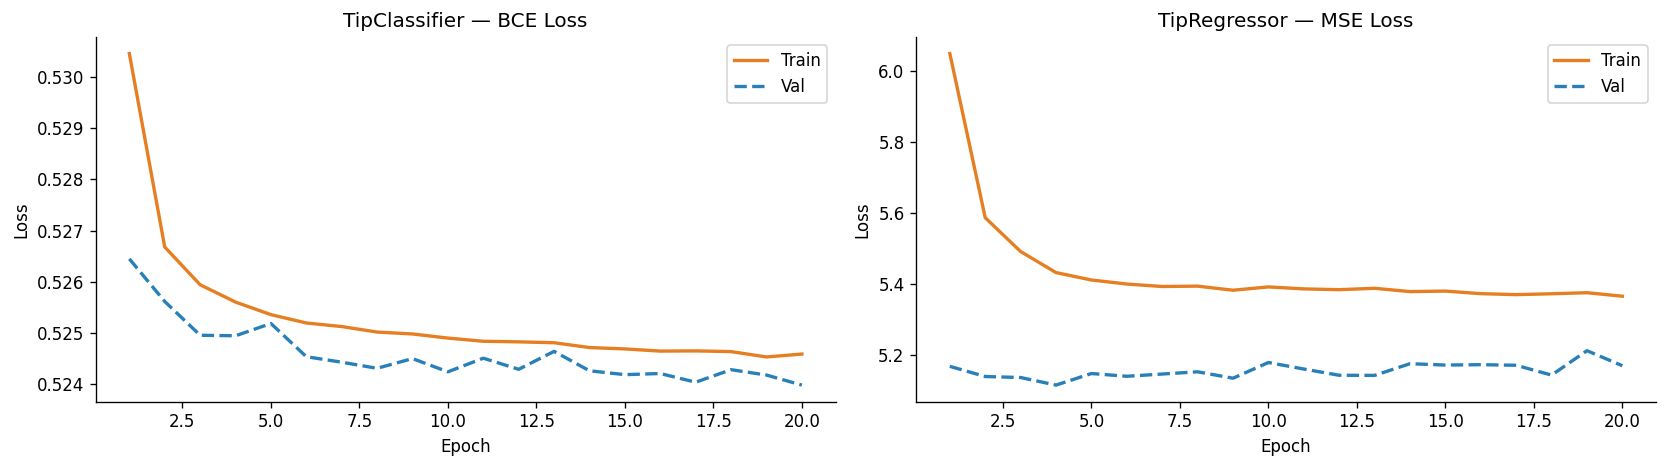

In [21]:
# plot training and validation loss curves for both networks
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, EPOCHS+1), clf_tr_loss, color="#e67e22", linewidth=2, label="Train")
axes[0].plot(range(1, EPOCHS+1), clf_vl_loss, color="#2980b9", linewidth=2, linestyle="--", label="Val")
axes[0].set_title("TipClassifier - BCE Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(range(1, EPOCHS+1), reg_tr_loss, color="#e67e22", linewidth=2, label="Train")
axes[1].plot(range(1, EPOCHS+1), reg_vl_loss, color="#2980b9", linewidth=2, linestyle="--", label="Val")
axes[1].set_title("TipRegressor - MSE Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
# runs inference on a dataloader and returns metrics, predictions and probabilities
def eval_nn(loader, true_labels):
    tip_net.eval()
    probs, preds = [], []
    with torch.no_grad():
        for Xb, _ in loader:
            p = torch.sigmoid(tip_net(Xb.to(compute_dev))).cpu().numpy().flatten()
            probs.extend(p)
            preds.extend((p >= 0.5).astype(int))
    return {"Model":     "PyTorch NN",
            "Accuracy":  accuracy_score(true_labels, preds),
            "Precision": precision_score(true_labels, preds, zero_division=0),
            "Recall":    recall_score(true_labels, preds, zero_division=0),
            "F1":        f1_score(true_labels, preds, zero_division=0),
            "AUC-ROC":   roc_auc_score(true_labels, probs),
            }, np.array(preds), np.array(probs)

# regression NN inference
def eval_nn_reg(loader, true_labels):
    tip_reg_net.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            p = tip_reg_net(Xb.to(compute_dev)).cpu().numpy().flatten()
            preds.extend(p)
    preds = np.array(preds)
    return {"Model": "PyTorch NN",
            "MAE":   mean_absolute_error(true_labels, preds),
            "RMSE":  np.sqrt(mean_squared_error(true_labels, preds)),
            "R2":    r2_score(true_labels, preds)}, preds

nn_val_scores,     nn_val_pred,     nn_val_prob  = eval_nn(vl_loader, y_cls_vl)
nn_reg_val_scores, nn_reg_val_pred               = eval_nn_reg(vl_reg_loader, y_reg_vl)

clf_scores.append(nn_val_scores)
reg_scores.append(nn_reg_val_scores)

print("Classification NN - Validation:")
print(pd.DataFrame([nn_val_scores]).to_string(index=False))
print("\nRegression NN - Validation:")
print(pd.DataFrame([nn_reg_val_scores]).to_string(index=False))

Classification NN - Validation:
     Model  Accuracy  Precision  Recall     F1  AUC-ROC
PyTorch NN    0.7713     0.7689  0.9994 0.8691   0.6201

Regression NN - Validation:
     Model    MAE   RMSE     R2
PyTorch NN 1.1884 2.2735 0.6426


In [23]:
print("All Classification Models - Validation Performance")
pd.DataFrame(clf_scores).drop_duplicates(subset="Model", keep="last").reset_index(drop=True)

All Classification Models - Validation Performance


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.7681,0.7683,0.9947,0.8670,0.6056
1,RF Classifier,0.7713,0.7694,0.9981,0.8690,0.6228
2,RF Classifier (Tuned),0.7712,0.7691,0.9986,0.8690,0.6209
3,PyTorch NN,0.7713,0.7689,0.9994,0.8691,0.6201


---

# Part 3: Model Evaluation & Interpretation

## 7. Comprehensive Evaluation

In [24]:
# evaluate all regression models on held-out test set
print("Regression Models - Test Set")
test_reg_results = {}

for name, model in regressors.items():
    s, pred = eval_regression(model, X_te, y_reg_te, name)
    test_reg_results[name] = {"metrics": s, "pred": pred}

# add regression NN to test results
nn_reg_test_scores, nn_reg_test_pred = eval_nn_reg(te_reg_loader, y_reg_te)
test_reg_results["PyTorch NN"] = {"metrics": nn_reg_test_scores, "pred": nn_reg_test_pred}

# sort by RMSE ascending
reg_summary = pd.DataFrame([v["metrics"] for v in test_reg_results.values()]).sort_values("RMSE")
reg_summary

Regression Models - Test Set


,Model,MAE,RMSE,R2
1,RF Regressor,1.1823,2.2675,0.6437
2,RF Regressor (Tuned),1.1941,2.2707,0.6427
3,PyTorch NN,1.1932,2.2936,0.6355
0,Linear Regression,1.2531,2.3557,0.6154


In [25]:
# evaluate all classification models on held-out test set
print("Classification Models - Test Set")
test_clf_results, clf_test_pred, clf_test_prob = [], {}, {}

for name, model in classifiers.items():
    s, pred, prob = eval_classification(model, X_te, y_cls_te, name)
    test_clf_results.append(s)
    clf_test_pred[name] = pred
    clf_test_prob[name] = prob

# evaluate neural network on test set
nn_test_scores, nn_test_pred, nn_test_prob = eval_nn(te_loader, y_cls_te)
test_clf_results.append(nn_test_scores)
clf_test_pred["PyTorch NN"] = nn_test_pred
clf_test_prob["PyTorch NN"] = nn_test_prob

# sort by AUC-ROC descending
clf_summary = pd.DataFrame(test_clf_results).sort_values("AUC-ROC", ascending=False)
clf_summary

Classification Models - Test Set


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
1,RF Classifier,0.7717,0.7696,0.9983,0.8692,0.6221
2,RF Classifier (Tuned),0.7715,0.7693,0.9987,0.8691,0.6204
3,PyTorch NN,0.7716,0.7691,0.9993,0.8692,0.6197
0,Logistic Regression,0.7687,0.7686,0.9951,0.8673,0.6055


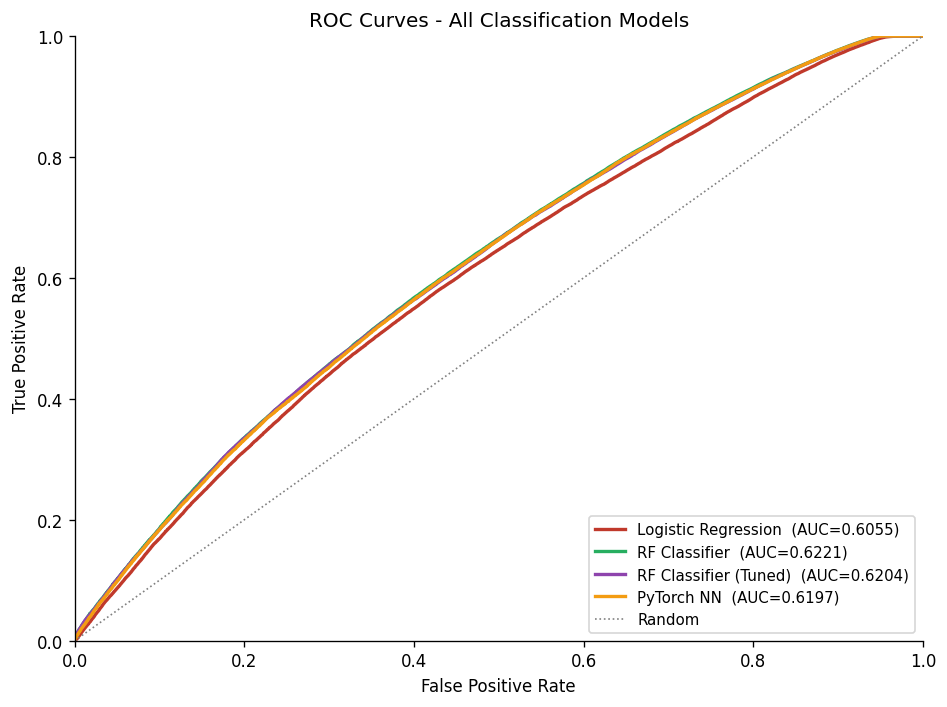

In [26]:
# ROC curves for all classification models on the test set
palette = ["#c0392b", "#27ae60", "#8e44ad", "#f39c12"]

fig, ax = plt.subplots(figsize=(8, 6))

for (name, probs), col in zip(clf_test_prob.items(), palette):
    fp_rate, tp_rate, _ = roc_curve(y_cls_te, probs)
    auc_val = roc_auc_score(y_cls_te, probs)
    ax.plot(fp_rate, tp_rate, label=f"{name}  (AUC={auc_val:.4f})",
            linewidth=2, color=col)

# random baseline
ax.plot([0, 1], [0, 1], color="grey", linewidth=1, linestyle=":", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - All Classification Models")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

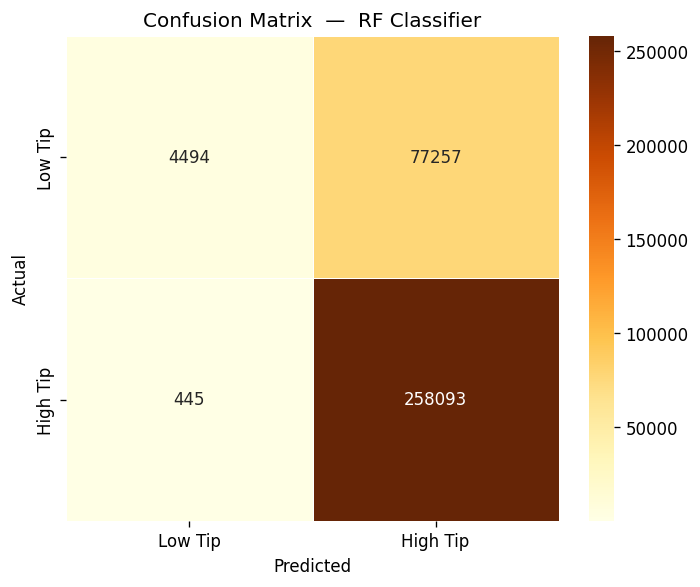

              precision    recall  f1-score   support

     Low Tip       0.91      0.05      0.10     81751
    High Tip       0.77      1.00      0.87    258538

    accuracy                           0.77    340289
   macro avg       0.84      0.53      0.49    340289
weighted avg       0.80      0.77      0.69    340289



In [27]:
# confusion matrix for the best classification model
top_clf      = clf_summary.iloc[0]["Model"]
top_clf_pred = clf_test_pred[top_clf]

conf_mat = confusion_matrix(y_cls_te, top_clf_pred)
fig, ax  = plt.subplots(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlOrBr", ax=ax,
            xticklabels=["Low Tip", "High Tip"],
            yticklabels=["Low Tip", "High Tip"],
            linewidths=0.5, linecolor="white")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix  -  {top_clf}")
plt.tight_layout()
plt.show()

# full classification report
print(classification_report(y_cls_te, top_clf_pred, target_names=["Low Tip", "High Tip"]))

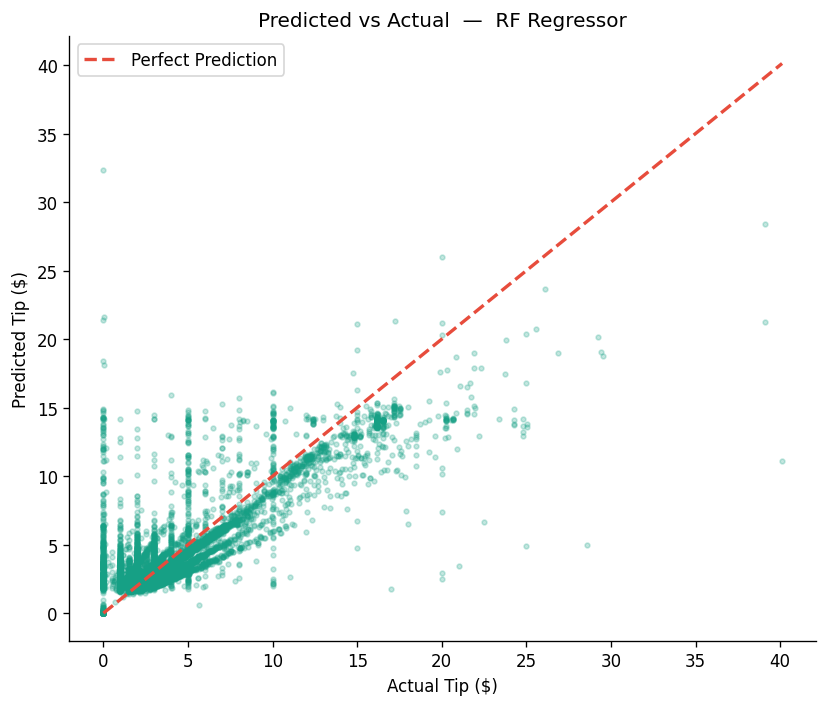

In [28]:
# predicted vs actual scatter plot for the best regression model (10k sample for clarity)
top_reg      = reg_summary.iloc[0]["Model"]
top_reg_pred = test_reg_results[top_reg]["pred"]
errors       = y_reg_te - top_reg_pred

rnd       = np.random.RandomState(SEED)
sample_idx = rnd.choice(len(y_reg_te), 10_000, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_reg_te[sample_idx], top_reg_pred[sample_idx],
           alpha=0.25, s=8, color="#16a085")
max_val = max(y_reg_te[sample_idx].max(), top_reg_pred[sample_idx].max())
ax.plot([0, max_val], [0, max_val], color="#e74c3c", linewidth=2,
        linestyle="--", label="Perfect Prediction")
ax.set_xlabel("Actual Tip ($)")
ax.set_ylabel("Predicted Tip ($)")
ax.set_title(f"Predicted vs Actual  -  {top_reg}")
ax.legend()
plt.tight_layout()
plt.show()

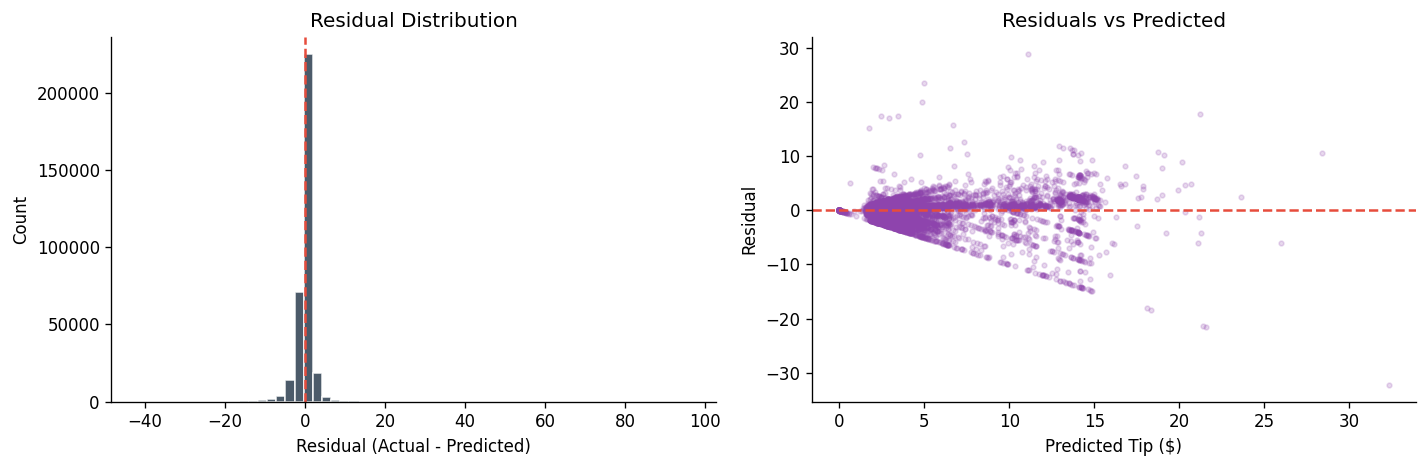

  residual mean : -0.0013
  residual std  : 2.2675


In [29]:
# residual distribution and residuals vs predicted values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(errors, bins=60, color="#2c3e50", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="#e74c3c", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Residual (Actual - Predicted)")
axes[0].set_ylabel("Count")
axes[0].set_title("Residual Distribution")

# heteroscedasticity check
axes[1].scatter(top_reg_pred[sample_idx], errors[sample_idx],
                alpha=0.2, s=8, color="#8e44ad")
axes[1].axhline(0, color="#e74c3c", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted Tip ($)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

print(f"  residual mean : {errors.mean():.4f}")
print(f"  residual std  : {errors.std():.4f}")

## 8. Feature Importance

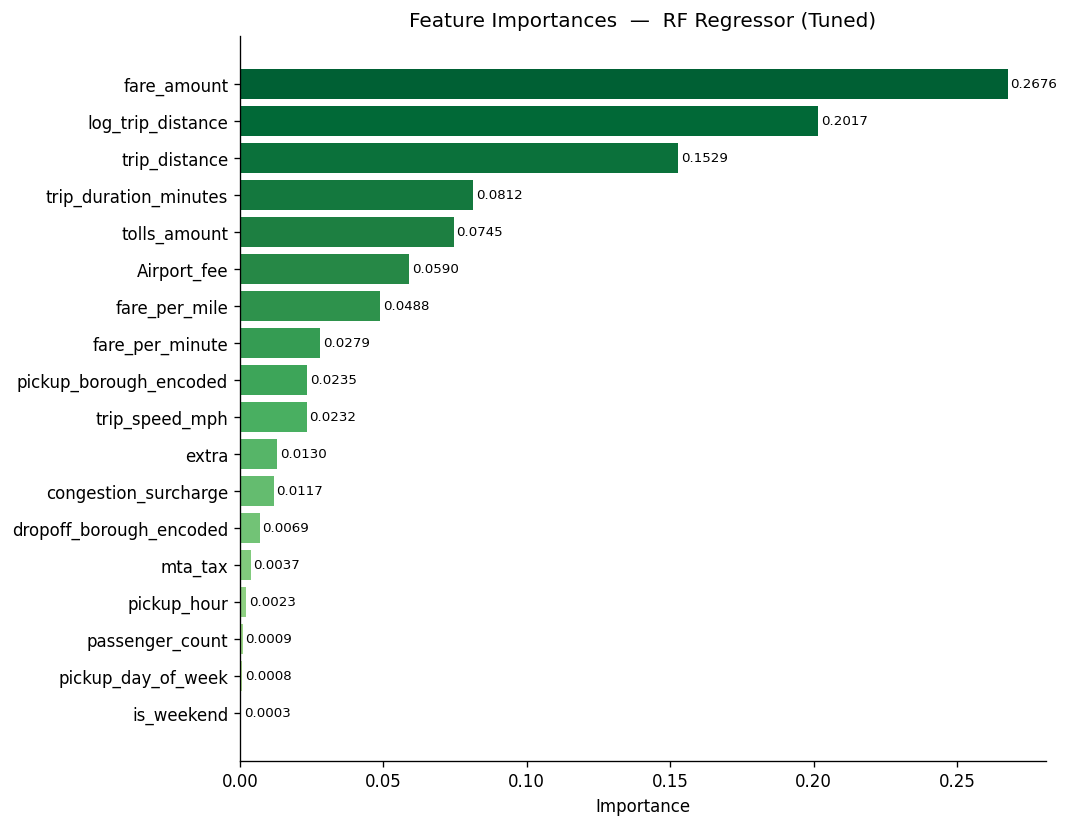


Top 10 features:
               Feature  Importance
           fare_amount      0.2676
     log_trip_distance      0.2017
         trip_distance      0.1529
 trip_duration_minutes      0.0812
          tolls_amount      0.0745
           Airport_fee      0.0590
         fare_per_mile      0.0488
       fare_per_minute      0.0279
pickup_borough_encoded      0.0235
        trip_speed_mph      0.0232


In [30]:
# feature importances from tuned RF regressor, sorted ascending for horizontal bar chart
feat_imp = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": regressors["RF Regressor (Tuned)"].feature_importances_
}).sort_values("Importance")

cmap_vals = plt.cm.YlGn(np.linspace(0.35, 0.9, len(feat_imp)))

fig, ax = plt.subplots(figsize=(9, 7))
bar_plot = ax.barh(feat_imp["Feature"], feat_imp["Importance"],
                   color=cmap_vals, edgecolor="none")

# value labels on each bar
for bar, val in zip(bar_plot, feat_imp["Importance"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)

ax.set_xlabel("Importance")
ax.set_title("Feature Importances  -  RF Regressor (Tuned)")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.iloc[::-1].head(10)[["Feature", "Importance"]].to_string(index=False))

**Linear Regression Coefficients**

`fare_amount` (2.6143) is the dominant predictor as tips scale directly with fare cost. `log_trip_distance` (0.8215) confirms longer trips tip more, while `trip_duration_minutes` (−0.4785) is negative, penalizing slow traffic-heavy trips. `congestion_surcharge` (0.4547) and `tolls_amount` (0.4295) act as proxies for premium routes like airports and highways. `trip_distance` (−0.3396) is negative due to multicollinearity with `log_trip_distance`, interpret them together not in isolation. Temporal and passenger features such as `pickup_hour` (0.0472), `is_weekend` (−0.0298) and `passenger_count` (0.0186) have near-zero coefficients, contributing minimally once trip and fare features are accounted for.

In [31]:
# linear regression coefficients sorted by absolute value to show most influential features
reg_coefs = pd.DataFrame({
    "Feature":     FEATURES,
    "Coefficient": regressors["Linear Regression"].coef_
}).assign(AbsCoef=lambda x: x["Coefficient"].abs()).sort_values("AbsCoef", ascending=False)

print("Linear Regression Coefficients (|coef| sorted):")
print(reg_coefs[["Feature", "Coefficient"]].to_string(index=False))

Linear Regression Coefficients (|coef| sorted):
                Feature  Coefficient
            fare_amount       2.6143
      log_trip_distance       0.8215
  trip_duration_minutes      -0.4785
   congestion_surcharge       0.4547
           tolls_amount       0.4295
          trip_distance      -0.3396
            Airport_fee       0.2456
 pickup_borough_encoded       0.2310
                  extra       0.1892
         trip_speed_mph      -0.1727
          fare_per_mile       0.0854
            pickup_hour       0.0472
                mta_tax       0.0311
             is_weekend      -0.0298
        fare_per_minute      -0.0281
dropoff_borough_encoded      -0.0208
        passenger_count       0.0186
     pickup_day_of_week       0.0039


**Logistic Regression Coefficients**

Unlike the regression model, `log_trip_distance` (−0.4609) is now the strongest predictor and is negative, meaning longer trips actually decrease the probability of a high tip. This makes sense as longer trips generate higher absolute fares making the 20% threshold harder to exceed. `congestion_surcharge` (0.2038) is the strongest positive predictor, suggesting surcharge trips (Manhattan, peak hours) are more likely to receive high tips. `trip_duration_minutes` (−0.1848) is again negative, slow trips reduce the likelihood of a high tip. `trip_distance` (0.1259) is positive here while `log_trip_distance` is negative, again a multicollinearity effect between the two distance features. `fare_amount` (0.1004) is much weaker here than in the regression model since the classification target is a ratio of tip to fare, so the raw fare matters less than trip characteristics. Temporal and demographic features such as `is_weekend` (0.0058), `pickup_day_of_week` (−0.0083) and `passenger_count` (0.0231) remain near-zero, contributing minimally to the classification decision.

In [32]:
# logistic regression coefficients sorted by absolute value, positive = increases P(high tip)
clf_coefs = pd.DataFrame({
    "Feature":     FEATURES,
    "Coefficient": classifiers["Logistic Regression"].coef_[0]
}).assign(AbsCoef=lambda x: x["Coefficient"].abs()).sort_values("AbsCoef", ascending=False)

print("Logistic Regression Coefficients (|coef| sorted):")
print(clf_coefs[["Feature", "Coefficient"]].to_string(index=False))

Logistic Regression Coefficients (|coef| sorted):
                Feature  Coefficient
      log_trip_distance      -0.4609
   congestion_surcharge       0.2038
  trip_duration_minutes      -0.1848
          trip_distance       0.1259
 pickup_borough_encoded       0.1227
            fare_amount       0.1004
          fare_per_mile      -0.0892
            Airport_fee       0.0775
                  extra       0.0744
           tolls_amount       0.0728
            pickup_hour       0.0605
        passenger_count       0.0231
dropoff_borough_encoded      -0.0182
         trip_speed_mph      -0.0113
     pickup_day_of_week      -0.0083
        fare_per_minute       0.0079
             is_weekend       0.0058
                mta_tax       0.0016


### SHAP Values

**SHAP Value Interpretation - 3 Sample Trips**

All three trips predict low tip amounts ($2.37, $2.24, $4.00), consistent with short, low-fare trips. Across all trips `fare_amount` and distance-related features (`log_trip_distance`, `trip_distance`) carry the largest negative SHAP values, meaning they are actively pushing predictions down. This reflects that these trips had below-average fares and distances relative to the training data.

Trip 1 ($2.37) is driven almost entirely negative by `fare_amount` (−0.5860), `log_trip_distance` (−0.3753) and `trip_distance` (−0.3192). The only positive contribution is `congestion_surcharge` (0.0403), suggesting the trip occurred in a surcharge zone which slightly boosted the predicted tip.

Trip 2 ($2.24) follows the same pattern with even stronger negative pulls from `fare_amount` (−0.7000) and distance features. `pickup_hour` (0.0460) and `extra` (0.0405) provide small positive contributions, indicating the pickup time and extra charges slightly offset the low fare effect.

Trip 3 ($4.00) is noticeably higher than the other two. While `fare_amount` (−0.2278) still pushes the prediction down, its effect is much weaker. `fare_per_mile` (0.0848), `trip_duration_minutes` (0.0592) and `pickup_hour` (0.0443) all contribute positively, suggesting this trip had a higher fare efficiency and occurred at a peak tipping hour, resulting in a higher predicted tip despite a similarly modest fare.


In [35]:
# SHAP values to explain individual predictions for 3 sample trips
top_rf    = regressors["RF Regressor (Tuned)"]
trip_idx  = np.random.RandomState(SEED).choice(len(X_te), 3, replace=False)
X_explain = X_te[trip_idx]

# tree explainer is fast for random forest models
tree_exp = shap.TreeExplainer(top_rf)
sv       = tree_exp.shap_values(X_explain)

# top 10 most influential features per trip
for i in range(3):
    sv_df = pd.DataFrame({
        "Feature":       FEATURES,
        "Feature Value": X_explain[i],
        "SHAP Value":    sv[i],
    }).sort_values("SHAP Value", key=abs, ascending=False)

    predicted = top_rf.predict(X_explain[i:i+1])[0]
    print(f"[ trip {i+1} ]  predicted tip: ${predicted:.2f}")
    print("-" * 55)
    print(sv_df.head(10).to_string(index=False))
    print("-" * 55)

[ trip 1 ]  predicted tip: $2.37
-------------------------------------------------------
              Feature  Feature Value  SHAP Value
          fare_amount        -0.5806     -0.5860
    log_trip_distance        -0.8489     -0.3753
        trip_distance        -0.5591     -0.3192
trip_duration_minutes        -0.6186     -0.2399
         tolls_amount        -0.2642     -0.0887
                extra        -0.8618     -0.0730
          Airport_fee        -0.2933     -0.0616
 congestion_surcharge         0.2521      0.0403
          pickup_hour        -0.7643     -0.0394
        fare_per_mile         0.6411     -0.0217
-------------------------------------------------------
[ trip 2 ]  predicted tip: $2.24
-------------------------------------------------------
              Feature  Feature Value  SHAP Value
          fare_amount        -0.7057     -0.7000
    log_trip_distance        -0.9771     -0.4129
        trip_distance        -0.5935     -0.3595
trip_duration_minutes        -0

## 9. Written Analysis

### a) Best Models

**Regression:** The baseline RF Regressor (MAE=1.1823, RMSE=2.2675, R²=0.6437) was the best performing model, marginally ahead of the tuned version (MAE=1.1941, RMSE=2.2707, R²=0.6427), suggesting default parameters were already well-suited to this dataset. The PyTorch regression NN (MAE=1.1932, RMSE=2.2936, R²=0.6355) came in third, performing comparably to the RF models but not surpassing them. Linear Regression was the weakest (MAE=1.2531, RMSE=2.3557, R²=0.6154), confirming tip prediction involves non-linear relationships a linear model cannot capture. The R²=0.64 across the top models means roughly 64% of tip variance is explained, with the remainder likely driven by unobservable factors like service quality.

**Classification:** All models achieved similar accuracy (around 77%) and near perfect recall (around 99%), but AUC-ROC scores of 0.60–0.62 reveal only modest discriminative ability. The RF Classifier led with AUC-ROC=0.6221, followed by RF Classifier Tuned (0.6204), PyTorch NN (0.6197) and Logistic Regression (0.6055). The high recall with moderate precision indicates all models are biased toward predicting the majority class, suggesting the 20% threshold task is inherently difficult with trip-level features alone.

### b) Most Predictive Features

`fare_amount` (0.2676) is the strongest predictor, directly aligning with intuition since tips are a percentage of fare. `log_trip_distance` (0.2017) and `trip_distance` (0.1529) together account for 35% of importance. `trip_duration_minutes` (0.0812), `tolls_amount` (0.0745) and `Airport_fee` (0.0590) capture trip cost and route type. `fare_per_mile` (0.0488), `fare_per_minute` (0.0279), `pickup_borough_encoded` (0.0235) and `trip_speed_mph` (0.0232) contribute marginally. Temporal features like `pickup_hour` and `is_weekend` did not rank in the top 10, meaning time of day adds little once fare and distance are accounted for.

### c) Limitations

Only credit card trips are modelled so cash tipping behaviour is entirely unobserved. January 2024 data only may not represent seasonal patterns. No service quality signal exists as driver ratings, traffic and tip prompt values are absent. `fare_amount` being both the strongest predictor and closely related to the target means the model partially learns a near-identity relationship rather than fully generalizable patterns. `total_amount` was correctly excluded as it directly contains `tip_amount`.

### d) Potential Improvements

Gradient boosting methods like XGBoost or LightGBM would likely improve performance over standard Random Forests. Adding weather, event and traffic data would provide context the current features cannot capture. Extending beyond one month would reduce temporal bias. Zone-level target encoding for `PULocationID`/`DOLocationID` would give finer location signal than borough encoding. Class-weight adjustments would improve identification of low tippers rather than defaulting to the majority class.

### e) Neural Network vs Traditional ML

Two neural networks were trained, `TipClassifier` for classification and `TipRegressor` for regression - both using the same two hidden layer architecture with ReLU and Dropout. Neither offered a meaningful advantage over the tree-based models. The regression NN (RMSE=2.2936, R²=0.6355) was slightly weaker than the RF baseline, and the classification NN (AUC-ROC=0.6197) was similarly matched. The convergence behaviour of both networks was notably flat, with loss barely decreasing after epoch 3, suggesting the networks quickly saturated the learnable signal in the 18 features. With such a small feature space Random Forests are the better choice, being faster to train, requiring no scaling, and providing direct interpretability through feature importances. The near-identical performance across all models confirms that model capacity is not the bottleneck - the task itself is the limiting factor.

## Final Model Summary

In [ ]:
print("REGRESSION - TEST SET")
print(reg_summary.to_string(index=False))

print("\nCLASSIFICATION - TEST SET")
print(clf_summary.to_string(index=False))

REGRESSION — TEST SET
               Model    MAE   RMSE     R2
        RF Regressor 1.1823 2.2675 0.6437
RF Regressor (Tuned) 1.1941 2.2707 0.6427
          PyTorch NN 1.1932 2.2936 0.6355
   Linear Regression 1.2531 2.3557 0.6154

CLASSIFICATION — TEST SET
                Model  Accuracy  Precision  Recall     F1  AUC-ROC
        RF Classifier    0.7717     0.7696  0.9983 0.8692   0.6221
RF Classifier (Tuned)    0.7715     0.7693  0.9987 0.8691   0.6204
           PyTorch NN    0.7716     0.7691  0.9993 0.8692   0.6197
  Logistic Regression    0.7687     0.7686  0.9951 0.8673   0.6055


---

## AI Tools Used

**Chat GPT:** Used for debugging assistance, explaining concepts and accelerating repetitive code patterns. All code was reviewed and understood before submission.